Trying to understand unique characteristics of the person sitting right and left. We will start from the frames where 2 people are detected (because they are almost all with person1 and person2) and from there we will "learn" unique characteristics of each

In [158]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import math
from scipy.spatial.distance import cdist

In [159]:
# Select candidates 

person1 = 'Martins'
person2 = 'Seguro'

In [160]:
# Load visual pkl for debate with person 1 and person 2 OR all debates with person 1 OR all debates
# find debate name that contains both candidates

pklfiles = []
if not person1:
    for file in os.listdir('../Project_Features'):
        if file.endswith('visual.pkl'):
            pklfiles.append(file)
elif not person2:
    for file in os.listdir('../Project_Features'):
        if file.endswith('visual.pkl') and person1 in file:
            pklfiles.append(file)
else:
    for file in os.listdir('../Project_Features'):
        if file.endswith('visual.pkl') and person1 in file and person2 in file:
            pklfiles.append(file)
            

debate_names = [f.replace('_visual.pkl', '') for f in pklfiles]
print("debates loaded:", debate_names)

data_raw = []
for video in pklfiles:
    print(f"Loading: {video}")
    df = pd.read_pickle(os.path.join('../Project_Features', video))
    data_raw.append(df)

data_raw = pd.concat(data_raw, ignore_index=True)

data_raw['Video_Name'] = data_raw['Frame'].str.extract(r'Frames/([^/]+)/')
data_raw['Frame_Number'] = data_raw['Frame'].str.extract(r'frame_(\d+)\.jpg').astype(int)
data = data_raw.sort_values(by=['Video_Name', 'Frame_Number']).reset_index(drop=True)


debates loaded: ['Seguro_vs_Martins_December_6']
Loading: Seguro_vs_Martins_December_6_visual.pkl


## Filter Out gestual language interpreters (if they exist)

The thresholds used to detect if a person is a gestual language interpreter were determined with the plots (see Helper Plots+Functions). 
Initially, we hadn't filtered them out and we plotted the y_center of the face bbox and teh face area to choose the threshold.
- if you want to check just set y_cut and area_cut to zero, run all and check the plots

In [ ]:
Y_CUT    = 450    
AREA_CUT = 8000

def is_interpreter(face, y_cut=Y_CUT, area_cut=AREA_CUT):
    x1, y1, x2, y2 = face['bbox']
    yc   = (y1 + y2) / 2
    area = (x2 - x1) * (y2 - y1)
    return (yc > y_cut) and (area < area_cut)   # BOTH low AND small

## Build Data Frame
- One person per row (body and face matched).
- All ratios are already calculated (check the landmarks positions in the next cell)

In [162]:
def dist(a, b): # a and b are tuples (x,y)
    x = b[0]-a[0]
    y = b[1]-a[1]
    return math.sqrt(x**2 + y**2)

master_data = []

for index, row in data_raw.iterrows():
    frame_id = row['Frame']
    frame_number = row['Frame_Number']
    faces = row['Fer']
    poses = row['Poses'] 
    
    if isinstance(faces, list) and len(faces) > 0:
        #check if faces is a dict (and if it has bbox probbaly has the other keys)
        valid_faces = [f for f in faces if isinstance(f, dict) and 'bbox' in f]
        # filter - GESTUAL LANGUAGE 
        valid_faces = [f for f in valid_faces if not is_interpreter(f)]
    else:
        valid_faces =[]

    
    people_count = len(valid_faces)

    if 0<people_count <=3:
        for i, face in enumerate(valid_faces):
            # 1. Face Coordinates
            f_box = face['bbox'] # [x1, y1, x2, y2]
            f_width = f_box[2] - f_box[0]
            f_height = f_box[3] - f_box[1]
            
            f_x_center = f_box[0] + (f_width / 2)
            f_y_center = f_box[1] + (f_height / 2) 
            face_area = f_width * f_height

            # ------- ratio 1----------
            #face width / face height ratio
            ratio_face = f_width/f_height
            
            top_emotion = face.get('top_emotion')
            probability = face['probabilities'].get(top_emotion) if top_emotion and 'probabilities' in face else None
            landmarks = face.get('landmarks')

            # ----------RATIOS----------
            #lower vs upper face ratio
            upper_face = dist(landmarks[10],landmarks[26])
            lower_face = dist(landmarks[15], landmarks[31])
            ratio_up_low_face = upper_face/lower_face

            # inner eye distance/face width
            dist_eyes = dist(landmarks[89], landmarks[39])
            face_w = dist(landmarks[10], landmarks[26])
            ratio_eyes_face = dist_eyes/face_w

            dist_nose = dist(landmarks[72], landmarks[80])
            face_l = dist(landmarks[72], landmarks[0])
            ratio_nose_face = dist_nose/face_l

            dist_mouth= dist(landmarks[52], landmarks[61])
            ratio_mouth_eyes = dist_eyes / dist_mouth if dist_mouth >= 0.001 else 0

            nose_tip = landmarks[86]
            
            # MATCHING THE FACE TO TE BODY -- this way our df will have 1 person per row
            matched_body_bbox = None
            matched_pose_keypoints = None
            ratio_shoulder_face =None
            ratio_nose_shoulder = None 

            if isinstance(poses, list):
                for person in poses:
                    if isinstance(person, dict)and len(person) > 0:
                        b_box = person['bbox'] 
                        
                        # is the center of the face inside this body's bounding box?
                        #note that b_box[3] > bbox[1] because y axis goes down
                        if (b_box[0] <= f_x_center <= b_box[2]) and (b_box[1] <= f_y_center <= b_box[3]):
                            matched_body_bbox = b_box
                            #matrix 17x3 - assuming (x,y, prob)
                            matched_pose_keypoints = person.get('pose') 

                            #-----RATIOS--------
                            #ratio shoulder width /  face width
                            l_shoulder = matched_pose_keypoints[5][0:2]
                            r_shoulder = matched_pose_keypoints[6][0:2]
                            shoulder_width = abs(r_shoulder[0] - l_shoulder[0])
                            ratio_shoulder_face = shoulder_width/f_width

                            # nose offset
                            ratio_nose_shoulder = dist(nose_tip,r_shoulder)/dist(nose_tip,l_shoulder) if dist(nose_tip,l_shoulder) >= 0.001 else 0

                            break 
            
            # 3. Append everything safely
            master_data.append({
                'Frame': frame_id,
                'Frame_Number': frame_number,
                'People_Count': people_count,
                'Person_Index': i,
                'Face_X_Center': f_x_center,
                'Face_Y_Center': f_y_center,
                'Face_Area': face_area,
                'Face_BBox': f_box,
                'Body_BBox': matched_body_bbox,         
                'Top_Emotion': top_emotion,
                'Emotion_Prob': probability,
                'Landmarks': landmarks,
                'Pose_Keypoints': matched_pose_keypoints, 
                'Ratio_Face': ratio_face,
                'Ratio_Up_Low_Face': ratio_up_low_face,
                'Ratio_Eyes_Face': ratio_eyes_face,
                'Ratio_Nose_Face': ratio_nose_face,
                'Ratio_Shoulder_Face': ratio_shoulder_face,
                #'Ratio_Mouth_Eyes': ratio_mouth_eyes
                'Ratio_Nose_Shoulder' : ratio_nose_shoulder
            })
            
    else:
        # Handle empty frames
        master_data.append({
            'Frame': frame_id, 'Frame_Number': frame_number, 'People_Count': 0, 'Person_Index': None,
            'Face_X_Center': None,'Face_Y_Center': None, 'Face_Area': None, 'Face_BBox': None,
            'Body_BBox': None, 'Top_Emotion': None, 'Emotion_Prob': None,
            'Landmarks': None, 'Pose_Keypoints': None, 'Ratio_Face': None,
                'Ratio_Up_Low_Face': None, 'Ratio_Eyes_Face': None, 'Ratio_Nose_Face': None,
                'Ratio_Shoulder_Face': None, #'Ratio_Mouth_Eyes': None
                'Ratio_Nose_Shoulder': None
        })

df_people = pd.DataFrame(master_data)
print(f"Important data (df shape): {df_people.shape}")
df_people['People_Count'].value_counts()

Important data (df shape): (3222, 19)


People_Count
2    1548
1    1101
3     573
Name: count, dtype: int64

# Helper Functions + Plots 
### 1. Check landmarks numbers
Check the landmark positions - this was what allowed us to use the correct landmarks for our ratios

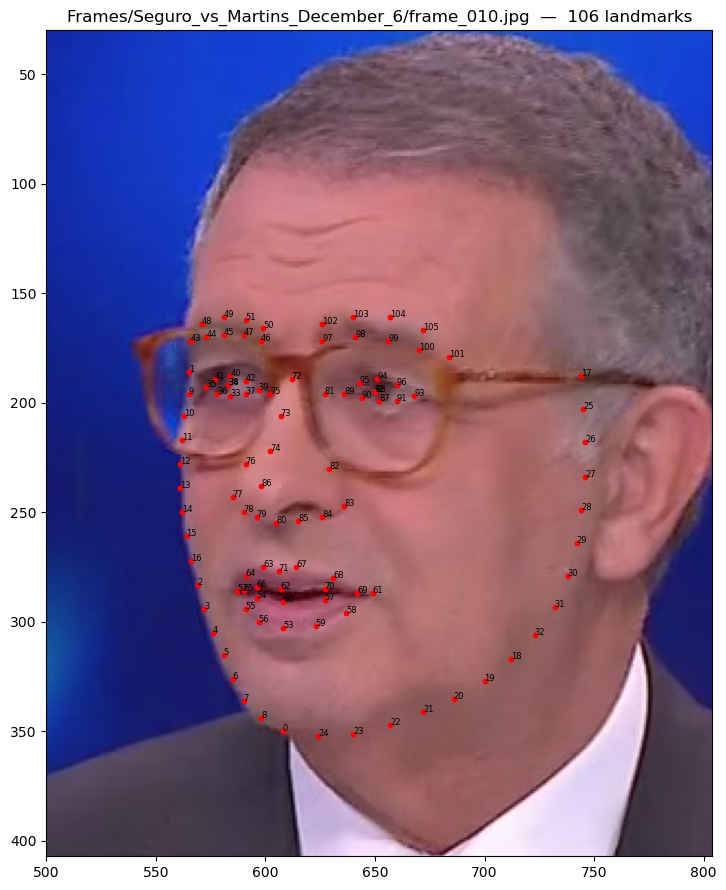

In [163]:

def get_landmarks_xy(lm):
    arr = np.asarray(lm, dtype=float)
    if arr.ndim == 1:
        arr = arr.reshape(106, 2)
    #elif arr.ndim == 2 and arr.shape[1] >= 2:
    #    arr = arr[:, 0:2]
    return arr

has_lm = df_people['Landmarks'].apply(lambda v: v is not None)
sample = df_people[has_lm & (df_people['People_Count'] == 1)]

sample = df_people[df_people['Frame_Number'] ==10]


for idx, row in sample.iterrows():
    pts  = get_landmarks_xy(row['Landmarks'])
    fbox = row['Face_BBox']                  

    fig, ax = plt.subplots(figsize=(9, 9))
    try:
        ax.imshow(Image.open(row['Frame']))
    except Exception as e:
        print(f"(no image for {row['Frame']}: {e}) — plotting points only")
    ax.scatter(pts[:, 0], pts[:, 1], s=10, c='red', zorder=3)
    for i, (x, y) in enumerate(pts):
        ax.annotate(str(i), (x, y), fontsize=6, color='black', zorder=4)

    if fbox is not None:                     # zoom to the face so indices are readable
        pad = 0.3 * (fbox[2] - fbox[0])
        ax.set_xlim(fbox[0] - pad, fbox[2] + pad)
        ax.set_ylim(fbox[3] + pad, fbox[1] - pad)   # inverted y (image coords)

    ax.set_title(f"{row['Frame']}  —  {len(pts)} landmarks")
    plt.tight_layout()
    plt.show()

### 2. Check the gestual language thresholds to be applied in the filters
We checked the y_center of the face bounding box (gestual language interpreters always have y_center > 450) and the area (gestual language face area is small, area < 10 000)

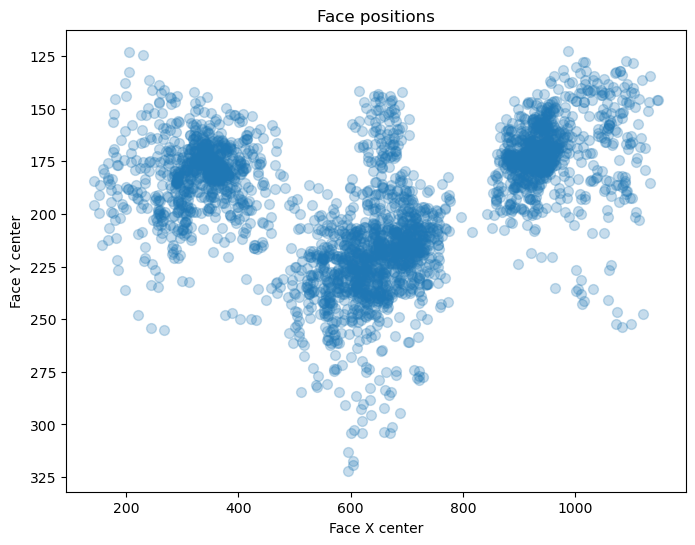

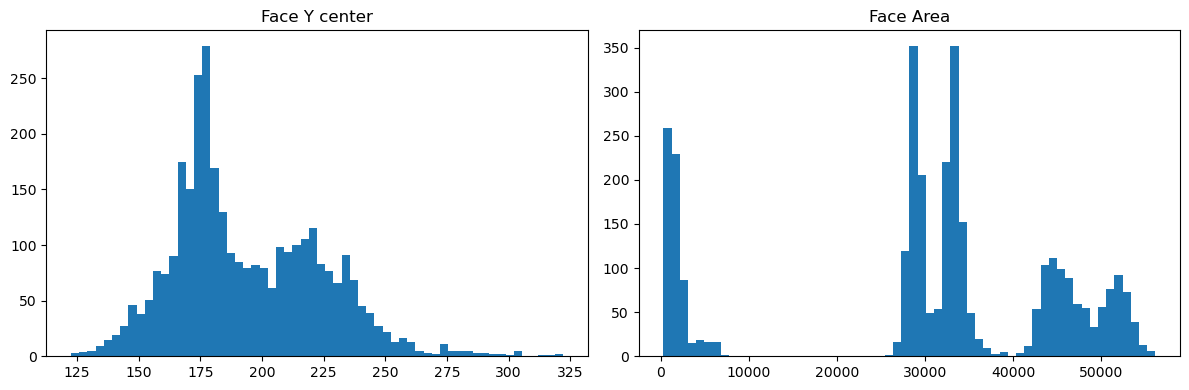

In [164]:
plt.figure(figsize=(8, 6))
plt.scatter(df_people['Face_X_Center'], df_people['Face_Y_Center'],
            s=50, alpha=0.25)
plt.gca().invert_yaxis()                       # so screen-bottom is at the bottom
plt.xlabel('Face X center'); plt.ylabel('Face Y center')
plt.title('Face positions')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df_people['Face_Y_Center'], bins=60); ax[0].set_title('Face Y center')
ax[1].hist(df_people['Face_Area'], bins=60); ax[1].set_title('Face Area')
plt.tight_layout()
plt.show()

# Fnding Unique Characteristics of Candidates (using 2 people frames)

Trying to understand unique characteristics of the person sitting right and left. We will start from the frames where 2 people are detected (because they are almost all with person1 and person2). We can understand if the ratios can slit well into 2 people (ideally we would see the 2 color bars well separated -- separated centroid)

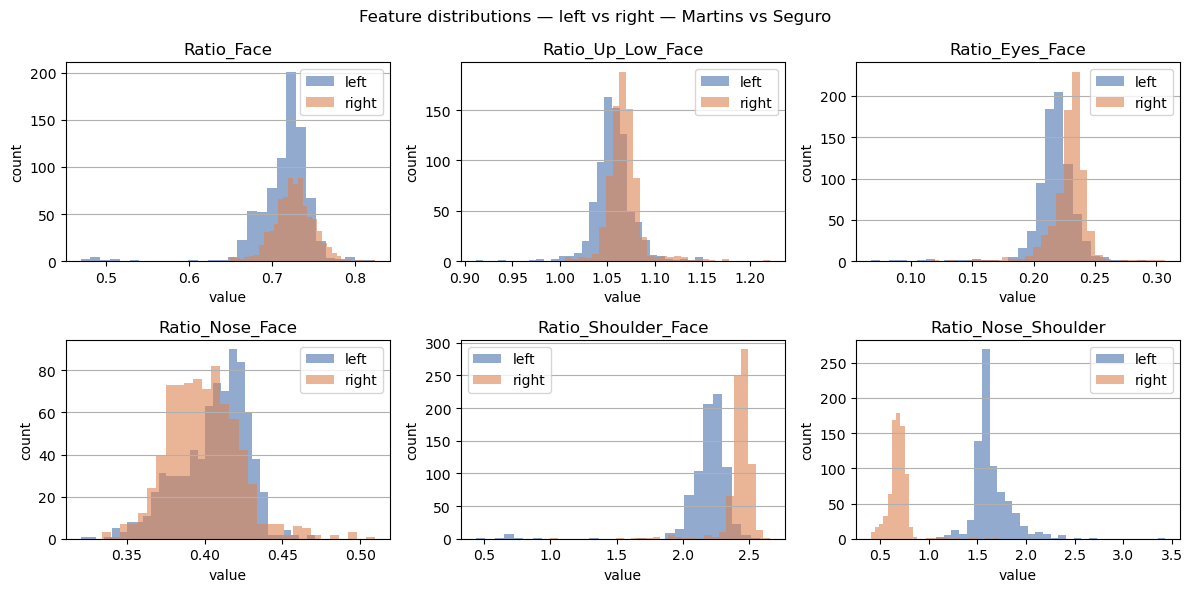

In [165]:
# filter the df_people (we want only 2-person frames)
df_two_people = df_people[df_people['People_Count'] == 2].copy()

#map data frame row (one person) to left or right
index_to_side = {}
# label left vs right based on x center
for frame_num, people in df_two_people.groupby('Frame_Number'):
    sorted_index = people.sort_values('Face_X_Center').index #sorts df index by the x center
    index_to_side[sorted_index[0]]= 'left'
    index_to_side[sorted_index[1]]='right'

df_two_people['side'] = df_two_people.index.map(index_to_side)

# plot distributions for each ratio
features = ['Ratio_Face', 'Ratio_Up_Low_Face', 'Ratio_Eyes_Face', 'Ratio_Nose_Face', 'Ratio_Shoulder_Face', 'Ratio_Nose_Shoulder']

fig, axes = plt.subplots(2,3,figsize=(12,6))

axes = axes.flatten()

for i in range(len(features)):
    ratio = features[i]
    ax = axes[i]

    mask_left = df_two_people['side']== 'left'
    mask_right = df_two_people['side'] == 'right'
    left_vals = df_two_people[mask_left][ratio].dropna()
    right_vals = df_two_people[mask_right][ratio].dropna()

    ax.hist(left_vals,  bins=30, alpha=0.6, color='#4C72B0', label='left')
    ax.hist(right_vals, bins=30, alpha=0.6, color='#DD8452', label='right')
    ax.set_title(ratio)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.grid(True, axis='y')
    ax.legend()

plt.suptitle(f'Feature distributions — left vs right — {person1} vs {person2}')
plt.tight_layout()
plt.show()

### Select the Ratios that separate the left and right candidate better

In [166]:
# select the best ratios (the ones that separate left and right better) and print their accuracy

def separation_accuracy(col_feature):
    d = df_two_people[['side', col_feature]].dropna()
    mask_left = d['side'] == 'left'
    mask_right = d['side'] == 'right'
    mean_left = d[mask_left][col_feature].dropna().mean()
    mean_right = d[mask_right][col_feature].dropna().mean()
    thr = (mean_left + mean_right) / 2

    #we want to understand if the threshold seprates left and right
    #compare with the bbox position and check correctness
    if mean_left > mean_right:
        #np.where (condition, value if true, val if false)
        pred = np.where(d[col_feature] >= thr, 'left', 'right')
    else:
        pred = np.where(d[col_feature] >= thr, 'right', 'left')

    sum_matches = pred == d['side'].values
    return sum_matches.mean()

features = ['Ratio_Face', 'Ratio_Up_Low_Face', 'Ratio_Eyes_Face', 'Ratio_Nose_Face', 'Ratio_Shoulder_Face', 'Ratio_Nose_Shoulder']

acc_dict ={}
print("Accuracy of each ratio in separating left vs right:")
for ratio in features:
    acc = separation_accuracy(ratio)
    acc_dict[ratio] = acc
    print(f"{ratio}: {acc*100 :.1f} %")

#Choose the ratios to use (dependent on the accuracy resuls)
def select_ratios(acc_dict:dict, identity_ratios=features[:-1], min_acc=0.65):
    ratios ={}
    high_acc = 0
    key_acc = None
    for rac in acc_dict.keys():
        if acc_dict[rac] >= min_acc:
            ratios[rac] = acc_dict[rac]
        if acc_dict[rac] > high_acc:
            high_acc = acc_dict[rac]
            key_acc = rac
    if len(ratios) ==0:
        ratios[key_acc] = high_acc

    #GUARANTEE that there is AT LEAST one if the identity ratios
    identity = False
    for rac in identity_ratios:
        if rac in ratios.keys():
            identity = True
            return ratios
    best_id = None
    best_acc = 0
    for rac in identity_ratios:
        if acc_dict[rac] > best_acc:
            best_acc = acc_dict[rac]
            best_id = rac
    ratios[best_id] = best_acc
    
    return ratios

#DEFINE THE minimum accuracy!!!!!!!
ratios_to_use = select_ratios(acc_dict, features[:-1], 0.7)
print(ratios_to_use.keys())



Accuracy of each ratio in separating left vs right:
Ratio_Face: 55.6 %
Ratio_Up_Low_Face: 64.7 %
Ratio_Eyes_Face: 73.8 %
Ratio_Nose_Face: 60.5 %
Ratio_Shoulder_Face: 90.6 %
Ratio_Nose_Shoulder: 99.3 %
dict_keys(['Ratio_Eyes_Face', 'Ratio_Shoulder_Face', 'Ratio_Nose_Shoulder'])


## Build 3 clusters across all data with the selected ratios

We will check the left candidate to have more counts in the cluster 0/1/2 and the right one to have more counts on cluster no 0/1/2. The moderator is the remaining cluster.

In [167]:
chosen_ratios = list(ratios_to_use.keys())   

# keep only faces that have ALL our chosen ratios
chosen_mask = df_people[chosen_ratios].notna().all(axis=1)
data = df_people[chosen_mask].copy()

# z score
X = StandardScaler().fit_transform(data[chosen_ratios])

n_comp = min(2, X.shape[0], X.shape[1])
if n_comp < 1:
    raise ValueError(f"Not enough data for PCA: X.shape={X.shape}")

pca = PCA(n_components=n_comp)
xy = pca.fit_transform(X)
data['px'] = xy[:,0]
data['py'] = xy[:,1] if n_comp>=2 else 0

print("this 2D view keeps", round(pca.explained_variance_ratio_.sum() * 100), "% of the info")

# LABEL in the 2 and 3 people shots (with bbox x center)
# here assuming the 2 people shots have left and right
# later we will double check
data['known'] = None
for frame, group in data[data['People_Count'] == 2].groupby('Frame_Number'):
    order = group.sort_values('Face_X_Center').index          # left, right
    if len(order) == 2:
        data.loc[order[0], 'known'] = 'left'
        data.loc[order[1], 'known'] = 'right'
for frame, group in data[data['People_Count'] == 3].groupby('Frame_Number'):
    order = group.sort_values('Face_X_Center').index          # left, centre, right
    if len(order) == 3:
        data.loc[order[0], 'known'] = 'left'
        data.loc[order[1], 'known'] = 'moderator'
        data.loc[order[2], 'known'] = 'right'


this 2D view keeps 86 % of the info


We will identify which cluster 0/1/2 corresponds to each person (left_candidate, right_candidate or moderator). How? We will use the 2 people shots, to evaluate that the person located left (bbox_x_center=left) falls more onto cluster 0/1/2, and the same for the person located right. The remaining cluster will be the moderator.

In [168]:
#data is the df that kept only the rows that had the 3 ratios
scaler = StandardScaler().fit(data[chosen_ratios])
Xz = scaler.transform(data[chosen_ratios])

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=0).fit(Xz)
data['cluster']      = gmm.predict(Xz)
data['cluster_conf'] = gmm.predict_proba(Xz).max(axis=1)   # confidence per face

two_rows = data[data['People_Count'] ==2]
tab = pd.crosstab(two_rows['cluster'], two_rows['known'])
print(tab) 

#iterate by row
# lEFT cluster
left_cluster = tab['left'].idxmax()

remaining =[]
for c in tab.index:
    if c != left_cluster:
        remaining.append(c)

#right cluster
right_cluster = tab.loc[remaining, 'right'].idxmax()

name_map = {left_cluster: 'candidate_left', right_cluster: 'candidate_right'}
for c in data['cluster'].dropna().unique():
    name_map.setdefault(c, 'moderator')

#DEFINE confidence thershold 
#now= 0.6
thrs_conf = 0.75

data['person'] = data['cluster'].map(name_map)
data.loc[data['cluster_conf'] < thrs_conf, 'person'] = 'uncertain'
print(data['person'].value_counts())

known    left  right
cluster             
0           0    729
1         732      0
2          38     41
person
candidate_left     1276
candidate_right    1212
moderator           635
uncertain            60
Name: count, dtype: int64


## Labelling (and revising the 2 people shots)

After knowing the cluster attributed to each person, we can finally label all detected people.
- 3 people shots: no doubt, just use the x_center of bbox
- 1 people shots: use the cluster
- 2 people: although it is most likely left and right, we can still have cases of (moderator+candidate). So first guess is left and right based on bbox, BUT we double check with the cluster to see if there is a match. If the bbox says: left and the cluster says: 2 (moderator), we check the cluster's confidence and if the cluster is pretty confident that it is "moderator", than we change the final_label to moderator

In [169]:
# unify the names, then take truth where known, model guess elsewhere
known_to_label = {
    'left':  'candidate_left',
    'right': 'candidate_right',
    'moderator': 'moderator',
}
data['final_label'] = data['known'].map(known_to_label) # the ones we know (2 and 3 people)
gap = data['final_label'].isna()                          # these are the 1-person close-ups
data.loc[gap, 'final_label'] = data.loc[gap, 'person']    # fill them with the clustered guess

print(data['final_label'].value_counts())


# double check the 2 people frames so we can evaluate possible cases in which we can have
# (moderator + candidate_left) OR (moderator + candidate_right)
MOD_OVERRIDE_CONF = 0.8      
two  = data['People_Count'] == 2
flip = two & (data['person'] == 'moderator') & (data['cluster_conf'] >= MOD_OVERRIDE_CONF)
data.loc[flip, 'final_label'] = 'moderator'

#-------- verification prints ------------
print("times it fired:", int(flip.sum()))

# BUT if we have 2 moderators in a frame - just say uncertain honestly
for frame_n, group in data.groupby('Frame_Number'):
    moderators = group[group['final_label'] == 'moderator'].index
    if len(moderators) >= 2: #if we have more than 1 moderator in frame
        data.loc[moderators, 'final_label'] = 'uncertain'

final_label
candidate_left     1455
candidate_right    1418
moderator           281
uncertain            29
Name: count, dtype: int64
times it fired: 73


## Plots
1. Screen time per candidate (counts the time they both appear)
2. People on screen across the time

final_label
candidate_left     1423
candidate_right    1380
moderator           269
uncertain            70
Name: Frame_Number, dtype: int64


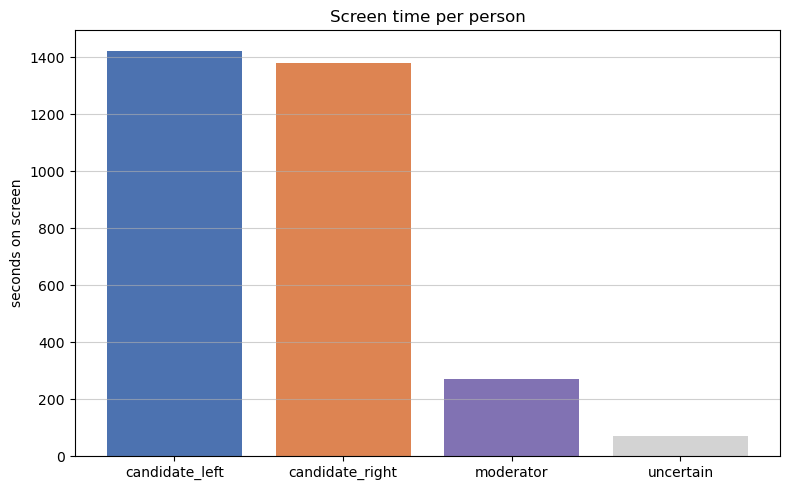

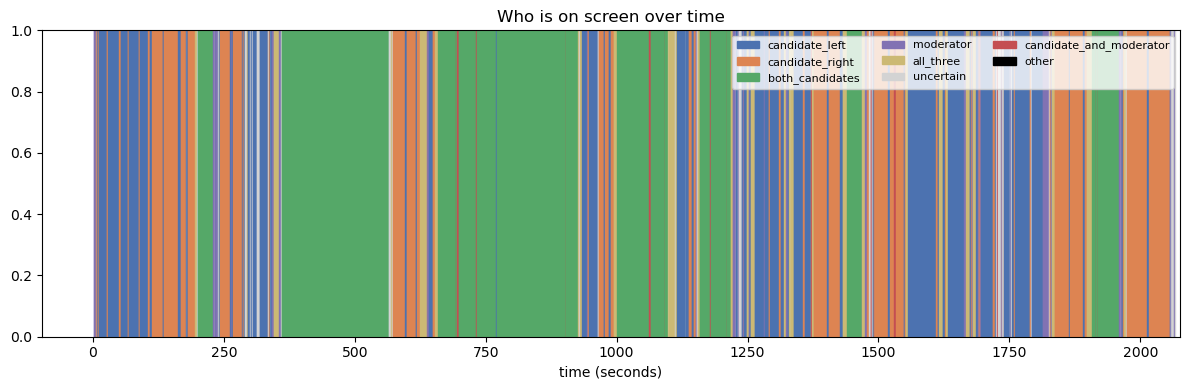

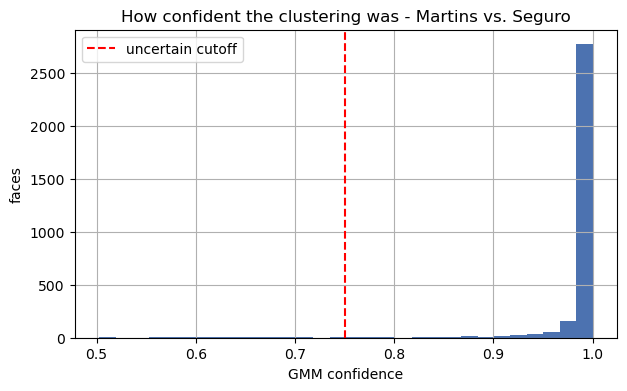

In [170]:
screen_time = data.groupby('final_label')['Frame_Number'].nunique().sort_values(ascending=False)
print(screen_time)

palette = {'candidate_left': '#4C72B0', 
           'candidate_right': '#DD8452',
           'moderator': '#8172B3', 
           'uncertain': 'lightgray'}

plt.figure(figsize=(8, 5))
plt.bar(screen_time.index, screen_time.values, color=[palette.get(l, 'gray') for l in screen_time.index])
plt.ylabel('seconds on screen'); plt.title('Screen time per person')
plt.tight_layout()
plt.grid(True, axis='y', alpha=0.6)
plt.show()

def summarize_frame(labels):
    labels = [l for l in labels if l != 'uncertain']   # ignore uncertain faces
    if len(labels) == 0:
        return 'uncertain'                             

    has_left      = 'candidate_left'  in labels
    has_right     = 'candidate_right' in labels
    has_moderator = 'moderator'       in labels

    if has_left and has_right and has_moderator:
        return 'all_three'
    if has_left and has_right:
        return 'both_candidates'
    if has_moderator and (has_left or has_right):
        return 'candidate_and_moderator'
    if len(set(labels)) == 1:
        return labels[0]
    return 'other'

frame_summary = data.groupby('Frame_Number')['final_label'].apply(summarize_frame)

color_map = {'candidate_left': '#4C72B0', 
             'candidate_right': '#DD8452', 
             'both_candidates': '#55A868',
             'moderator': '#8172B3',
             'all_three': '#CCB974', 
             'uncertain': 'lightgray',
             'candidate_and_moderator': '#C44E52',
             'other': 'black'}

plt.figure(figsize=(12, 4))
for frame_num, lab in frame_summary.items():
    plt.axvline(x=frame_num, color=color_map.get(lab, 'white'), linewidth=1)
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color=c, label=l) for l, c in color_map.items()],
           loc='upper right', ncol=3, fontsize=8)
plt.xlabel('time (seconds)'); plt.title('Who is on screen over time')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(data['cluster_conf'].dropna(), bins=30, color='#4C72B0')
plt.axvline(thrs_conf, color='red', linestyle='--', label='uncertain cutoff')
plt.xlabel('GMM confidence'); plt.ylabel('faces'); plt.legend()
plt.title(f'How confident the clustering was - {person1} vs. {person2}')
plt.grid(True)
plt.show()

## Check one frame

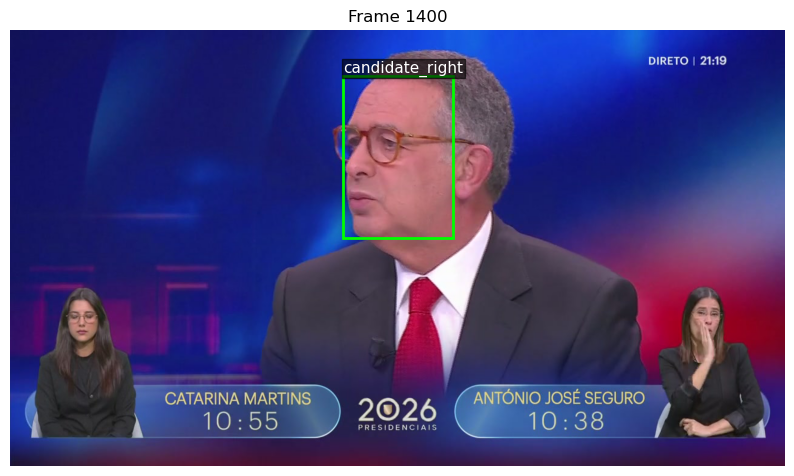

In [171]:
from matplotlib.patches import Rectangle

def show_frame(frame_number, df=data, label_col='final_label'):
    rows = df[df['Frame_Number'] == frame_number]
    if len(rows) == 0:
        print('no labelled faces in this frame'); return
    img = Image.open(rows.iloc[0]['Frame'])
    fig, ax = plt.subplots(figsize=(10, 6)); ax.imshow(img); ax.axis('off')
    for _, r in rows.iterrows():
        x1, y1, x2, y2 = r['Face_BBox']
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='lime', linewidth=2))
        ax.text(x1, y1 - 6, str(r[label_col]), color='white', fontsize=11,
                bbox=dict(facecolor='black', alpha=0.6, pad=1))
    ax.set_title(f'Frame {frame_number}'); plt.show()

show_frame(1400)

## Video to check labelling

In [172]:
import cv2
def make_video(df, out='labeled_debate.mp4', fps=5):
    frames = sorted(df['Frame_Number'].unique())
    h, w = cv2.imread(df[df.Frame_Number == frames[0]].iloc[0]['Frame']).shape[:2]
    vw = cv2.VideoWriter(out, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    bgr = {'candidate_left': (255, 0, 0), 'candidate_right': (0, 128, 255), 'moderator': (0, 200, 0), 'uncertain': (180, 180, 180)}
    for fn in frames:
        rows = df[df.Frame_Number == fn]
        img = cv2.imread(rows.iloc[0]['Frame'])
        for _, r in rows.iterrows():
            x1, y1, x2, y2 = map(int, r['Face_BBox'])
            c = bgr.get(r['final_label'], (255, 255, 255))
            cv2.rectangle(img, (x1, y1), (x2, y2), c, 2)
            cv2.putText(img, str(r['final_label']), (x1, max(0, y1 - 8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, c, 2)
        vw.write(img)
    vw.release(); print('saved', out)

make_video(data)

saved labeled_debate.mp4


# Audio Code (Dinis)

In [173]:
audio_files = sorted([f for f in os.listdir('../Project_Features') if f.endswith('_audio.pkl')])

dfs = []
for f in audio_files:
    df = pd.read_pickle(os.path.join('../Project_Features', f))
    df['video'] = f.replace('_audio.pkl', '')
    dfs.append(df)

data_audio = pd.concat(dfs, ignore_index=True)
print(f'Loaded {len(data_audio)} segments across {data_audio["video"].nunique()} videos')

Loaded 2656 segments across 28 videos


In [ ]:
def parse_embedding(s):
    if isinstance(s, np.ndarray):
        return s
    return np.fromstring(s.strip('[]'), sep=' ')

data_audio['speak_embeddings'] = data_audio['speak_embeddings'].apply(parse_embedding)

data_parties       = pd.read_pickle(os.path.join('../Project_Features', 'candidate_party.pkl'))
candidate_to_party = dict(zip(data_parties['Candidate'], data_parties['Party']))

CANDIDATES = [
    'Cotrim_Figueiredo', 'Filipe', 'Gouveia_Melo',
    'Marques_Mendes', 'Martins', 'Pinto', 'Seguro', 'Ventura'
]
debate_videos = sorted([v for v in data_audio['video'].unique() if 'vs' in v])

def extract_candidates(video_name):
    for c in CANDIDATES:
        if video_name.startswith(c):
            rest = video_name[len(c) + len('_vs_'):]
            for c2 in CANDIDATES:
                if rest.startswith(c2):
                    return c, c2
    return None, None

FileNotFoundError: [Errno 2] No such file or directory: 'Project_Features/candidate_party.pkl'

In [ ]:
debate_centroids = {}
cluster_col      = np.full(len(data_audio), -1, dtype=int)

for video_name in debate_videos:
    mask = data_audio['video'] == video_name
    idx  = data_audio.index[mask]
    E    = np.stack(data_audio.loc[idx, 'speak_embeddings'].values)
    km   = KMeans(n_clusters=3, random_state=42, n_init=10)
    lbls = km.fit_predict(E)
    cluster_col[idx]              = lbls
    debate_centroids[video_name]  = km.cluster_centers_

data_audio['cluster_k3'] = cluster_col
print(f'k=3 clustering done for {len(debate_centroids)} debates')

k=3 clustering done for 28 debates


In [ ]:
def candidate_centroid_per_debate(candidate, debate_centroids):
    their_debates = [v for v in debate_centroids if candidate in v]
    if len(their_debates) < 2:
        return {}
    best = {}
    for video in their_debates:
        others = [v for v in their_debates if v != video]
        cents  = debate_centroids[video]
        scores = [
            sum(cdist(cents[i].reshape(1,-1), debate_centroids[ov], metric='cosine')[0].min()
                for ov in others)
            for i in range(3)
        ]
        best[video] = cents[int(np.argmin(scores))]
    return best

global_centroids = {}
for cand in CANDIDATES:
    result = candidate_centroid_per_debate(cand, debate_centroids)
    if result:
        global_centroids[cand] = np.mean(np.stack(list(result.values())), axis=0)

print(f'Global centroids built for {len(global_centroids)} candidates')

# --- assign speaker labels ---
speaker_col = np.full(len(data_audio), 'unknown', dtype=object)

for video_name in debate_videos:
    cA, cB = extract_candidates(video_name)
    if cA is None:
        continue
    mask  = data_audio['video'] == video_name
    idx   = data_audio.index[mask]
    cents = debate_centroids[video_name]

    dist_A = cdist(cents, global_centroids[cA].reshape(1,-1), metric='cosine').flatten()
    dist_B = cdist(cents, global_centroids[cB].reshape(1,-1), metric='cosine').flatten()

    cluster_map = {}
    available   = {0, 1, 2}
    best_A = int(np.argmin([dist_A[i] if i in available else np.inf for i in range(3)]))
    cluster_map[best_A] = cA
    available.remove(best_A)
    best_B = int(np.argmin([dist_B[i] if i in available else np.inf for i in range(3)]))
    cluster_map[best_B] = cB
    available.remove(best_B)
    cluster_map[available.pop()] = 'host'

    labels = data_audio.loc[idx, 'cluster_k3'].values
    speaker_col[idx] = [cluster_map[l] for l in labels]

data_audio['speaker'] = speaker_col
data_audio['party']   = data_audio['speaker'].map(candidate_to_party).fillna('host')
print('Speaker assignment done.')

Global centroids built for 8 candidates
Speaker assignment done.


In [ ]:
#DEBATE = 'Martins_vs_Gouveia_Melo_November_23'  # change to match your file name exactly

#find debate name that contains both candidates

debate = debate_names[0] # I CHANGED THIS
#how do i make this work when we have multiple debates?

debate_audio = (
    data_audio[data_audio['video'] == debate]
    .copy()
    .sort_values('time stamp')
    .reset_index(drop=True)
)

debate_audio['frame_start'] = (debate_audio['time stamp'].apply(math.floor) + 1).astype(int)
debate_audio['frame_end']   = (debate_audio['time stamp'] + debate_audio['duration']).apply(math.ceil).astype(int)
debate_audio['frames']      = debate_audio.apply(
    lambda r: list(range(r['frame_start'], r['frame_end'] + 1)), axis=1
)

print(f'Audio segments for {debate}: {len(debate_audio)}')
print(debate_audio['speaker'].value_counts())

Audio segments for Martins_vs_Gouveia_Melo_November_23: 99
speaker
Gouveia_Melo    57
Martins         26
host            16
Name: count, dtype: int64


# Audio + Visual Integration

1. Match the identified speaker to the visual data frame

In [ ]:
# gather the columns that matter and put one frame per row. rename de cols to have the same name as visual df
audio_df = debate_audio[['video', 'frames', 'speaker']].explode('frames')
audio_df = audio_df.rename(columns={'video': 'Video_Name', 'frames':'Frame_Number'}) 
audio_df['Frame_Number'] = audio_df['Frame_Number'].astype(int)

# ensure one speaker per frame
audio_df = audio_df.drop_duplicates(subset=['Video_Name', 'Frame_Number'])

# remove any leftover speaker columns from earlier runs so the merge gives a clean 'speaker'
data = data.drop(columns=['speaker', 'speaker_x', 'speaker_y'], errors='ignore')

data['Video_Name'] = data['Frame'].str.extract(r'Frames/([^/]+)/')
data = data.merge(audio_df, on=['Video_Name', 'Frame_Number'], how='left')
data = data.sort_values(['Video_Name', 'Frame_Number']).reset_index(drop=True)

print(round(data['speaker'].notna().mean(), 2), "of clustered faces fall in a speaking moment")

0.88 of clustered faces fall in a speaking moment


## Understand who is candidate_left (is it Martins?) and vice versa

In [ ]:
one_person = data[(data['People_Count'] == 1) & data['speaker'].notna()]

tab_names = pd.crosstab(one_person['final_label'], one_person['speaker'])
print(tab_names)

# exclude the host (just for safety) because imagine if host had mpre counts
candidates = [c for c in tab_names.columns if c != 'host']
left_name = tab_names.loc['candidate_left', candidates].idxmax()

# who is candidate right
remaining_names =[]
for c in candidates:
    if c != left_name:
        remaining_names.append(c)

#right cluster
right_name = tab_names.loc['candidate_right', remaining_names].idxmax()

real = {'candidate_left': left_name, 'candidate_right': right_name,
        'moderator': 'moderator', 'uncertain': 'uncertain'}

data['final_name'] = data['final_label'].map(real)


speaker          Gouveia_Melo  Martins  host
final_label                                 
candidate_left             27      361    31
candidate_right           308       15    22
moderator                   5        9    46
uncertain                   3       13     8


              screen  voice
Gouveia_Melo    1481  648.0
Martins         1457  883.0
moderator        212  210.0
uncertain         54    0.0


<Figure size 800x400 with 0 Axes>

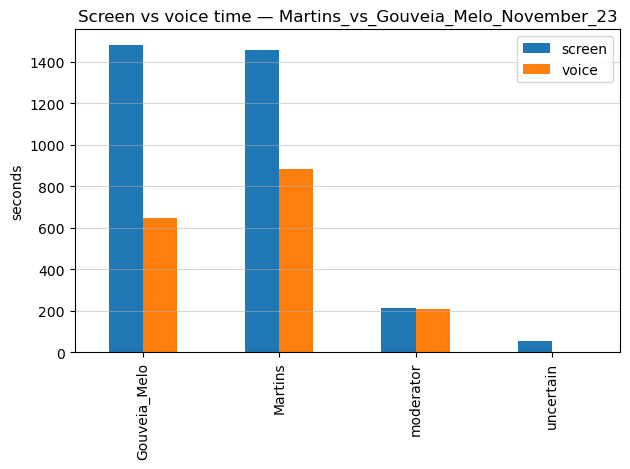

In [ ]:
# screen time: distinct frames each person appears in (1 fps, so frames = seconds)
screen = data.groupby('final_name')['Frame_Number'].nunique()

# voice time: total seconds each person is speaking
voice = debate_audio.groupby('speaker')['duration'].sum()
voice = voice.rename({'host': 'moderator'})    # align audio's 'host' with your 'moderator'

compare = pd.DataFrame({'screen': screen, 'voice': voice}).fillna(0).round(0)
print(compare)

plt.figure(figsize=(8,4))
compare[['screen', 'voice']].plot(kind='bar')
plt.ylabel('seconds'); 
plt.title(f'Screen vs voice time — {debate}')
plt.tight_layout()
plt.grid(True, axis='y', alpha=0.5)
plt.show()

In [ ]:
def make_qc_video(df, out='qc_name_vs_speaker.mp4', fps=5):
    # color by the stable role, label with the real name
    palette = {'candidate_left': (255, 0, 0), 'candidate_right': (0, 128, 255),
               'moderator': (0, 200, 0), 'uncertain': (180, 180, 180)}
    frames = sorted(df['Frame_Number'].unique())
    h, w = cv2.imread(df[df.Frame_Number == frames[0]].iloc[0]['Frame']).shape[:2]
    vw = cv2.VideoWriter(out, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

    for fn in frames:
        rows = df[df.Frame_Number == fn]
        img = cv2.imread(rows.iloc[0]['Frame'])

        # who the AUDIO says is talking this second ('host' -> 'moderator' to match visual names)
        spk = rows.iloc[0]['speaker']
        spk = 'moderator' if spk == 'host' else spk
        spk_txt = spk if isinstance(spk, str) else 'silence'

        for _, r in rows.iterrows():
            x1, y1, x2, y2 = map(int, r['Face_BBox'])
            color = palette.get(r['final_label'], (255, 255, 255))
            speaking = (r['final_name'] == spk)            # is THIS face the talker?
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 4 if speaking else 2)
            cv2.putText(img, str(r['final_name']), (x1, max(0, y1 - 8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        cv2.rectangle(img, (0, 0), (w, 30), (0, 0, 0), -1)   # banner
        cv2.putText(img, f'Speaking: {spk_txt}', (10, 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        vw.write(img)
    vw.release(); print('saved', out)

vis = data[data['Video_Name'] == debate]
make_qc_video(vis)

saved qc_name_vs_speaker.mp4


## Check when audio and visual agree (1 person shots)

0.87 of 1-person frames: visual name agrees with audio speaker
speaker_name  Gouveia_Melo  Martins  moderator
final_name                                    
Gouveia_Melo           308       15         22
Martins                 27      361         31
moderator                5        9         46


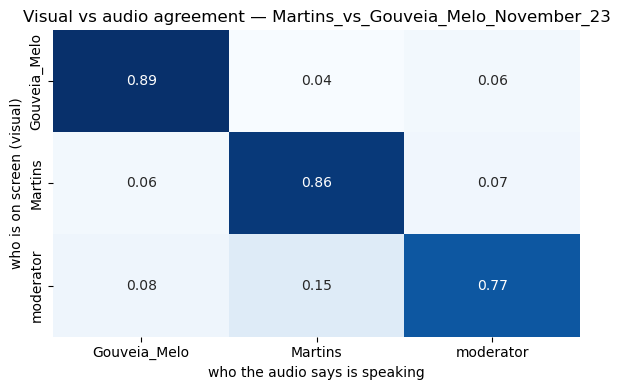

In [ ]:
one_shot = data[(data['People_Count']==1) & data['final_name'].isin([left_name, right_name, 'moderator']) & data['speaker'].notna()].copy()

one_shot['speaker_name'] = one_shot['speaker'].replace({'host':'moderator'})

agree=(one_shot['final_name']== one_shot['speaker_name']).mean()
print(round(agree, 2), "of 1-person frames: visual name agrees with audio speaker")
print(pd.crosstab(one_shot['final_name'], one_shot['speaker_name']))


# of the frames showing person X, what fraction had X actually speaking
ct = pd.crosstab(one_shot['final_name'], one_shot['speaker_name'], normalize='index')

plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='Blues', cbar=False)
plt.xlabel('who the audio says is speaking')
plt.ylabel('who is on screen (visual)')
plt.title(f'Visual vs audio agreement — {debate}')
plt.tight_layout()
plt.show()

In [ ]:
vis = data[data['Video_Name'] == debate]
people = [left_name, right_name, 'moderator']

screen = vis.groupby('final_name')['Frame_Number'].nunique()
voice  = debate_audio.groupby('speaker')['duration'].sum().rename({'host': 'moderator'})

summary = pd.DataFrame({'screen_s': screen, 'voice_s': voice}).reindex(people).fillna(0)
summary['screen_%'] = (100 * summary['screen_s'] / summary['screen_s'].sum()).round(1)
summary['voice_%']  = (100 * summary['voice_s']  / summary['voice_s'].sum()).round(1)
summary[['screen_s', 'voice_s']] = summary[['screen_s', 'voice_s']].round(0)
print(summary)

dp = df_people[df_people['Frame'].str.contains(debate)]
print("labelled faces:", len(vis), "of", len(dp),
      f"detected ({round(100 * len(vis) / len(dp))}% had usable ratios)")
print("uncertain faces:", int((vis['final_name'] == 'uncertain').sum()))

              screen_s  voice_s  screen_%  voice_%
Martins           1457    883.0      46.3     50.7
Gouveia_Melo      1481    648.0      47.0     37.2
moderator          212    210.0       6.7     12.1
labelled faces: 3231 of 3261 detected (99% had usable ratios)
uncertain faces: 81


In [ ]:
#data[['Video_Name','Frame_Number','Person_Index','final_label','final_name','speaker']].to_pickle('labels.pkl')